# 🥥 Demanda y oferta local de coco · Cocoil

**Proyecto:** coco-analytics · **Notebook 04** · julio 2026

Contrasta dos preguntas con datos:

1. **Demanda:** ¿el mercado boliviano aguanta la rampa del plan financiero (650 frascos/mes)?
2. **Oferta:** ¿hay coco boliviano suficiente — y dónde está *realmente*?

> Fuentes: Censo 2024 (INE), microdato INE de importaciones, tesis UMSA (86 % importado),
> Instituto Cruceño de Estadística (superficie/cosecha de coco), relevamiento propio.
> Detalle y confianza por dato en `datos/demanda_senales.csv` y `datos/oferta_coco_zonas.csv`.

## 🔎 Dos correcciones importantes que dejó esta investigación

- **El "misterio" de San Juan resuelto:** la cifra "27,5 ha / 8.250 t" que traíamos con
  cautela era una mala lectura — el Instituto Cruceño mide en **quintales**: San Juan ≈
  **28,5 ha y 8.340 qq ≈ 384 t de fruta/año** (rinde ~13,5 t/ha, plausible).
- **El Chapare NO tiene coco documentado** (su fruticultura es palmito, cítricos, banano).
  El coco boliviano real está en la **provincia Ichilo** (San Juan, Buena Vista, San
  Carlos, Yapacaní) y **Warnes**. Esto corrige el supuesto de los notebooks 01–02.


## 1. Preparación

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

BASE = Path.cwd()
ANALISIS = BASE if (BASE / "datos").exists() else BASE / "analisis"
DATOS = ANALISIS / "datos"
sys.path.append(str(ANALISIS.parent / "src"))
from estilo import aplicar_estilo, guardar, COCO
aplicar_estilo()

dem = pd.read_csv(DATOS / "demanda_senales.csv")
ofe = pd.read_csv(DATOS / "oferta_coco_zonas.csv")
display(dem)


,senal,valor,unidad,detalle,fuente,confianza
0,Poblacion Bolivia (Censo 2024),11365333,habitantes,Cifra final socializada por INE/UNFPA,INE Censo 2024,alta
1,Ciudad Santa Cruz de la Sierra,1903398,habitantes,La ciudad mas poblada y la que mas crecio,El Deber / INE,alta
2,La Paz + El Alto,1640767,habitantes,755.732 + 885.035 (municipios),ANF / Erbol / INE,alta
3,Cochabamba Cercado,661484,habitantes,Metro Kanata ~1.5M,Opinion / INE,alta
4,Cuota importada del consumo,86,%,Tesis UMSA: 86% del consumo nacional es importado,Tesis UMSA 26268,media
5,Mercado importado (INE),40-100,t/anio,Volumen oficial de importaciones 1513.11/1513.19,Microdato INE,alta
6,Precio minorista aceite de coco,60.35-73.77,Bs/kg,Santa Cruz y El Alto,Selina Wamucii,media
7,Comunidad keto La Paz,9564,likes FB,Keto Market La Paz; vende aceite Copra,Facebook,media
8,BeCoco (lider),11738,likes FB,La marca mas distribuida,Facebook,alta
9,Canal naturista en expansion,7,sucursales,Natural Farma: +350 productos naturales,naturalfarma.bo,alta


## 2. Demanda — el embudo del mercado direccionable

Partimos del único ancla dura (importaciones oficiales: **40–100 t/año**) y del dato de
la tesis UMSA (**86 % del consumo es importado** → total ≈ importado ÷ 0,86).
Contra eso, la rampa tope del plan financiero (650 frascos de 200 ml/mes = **1,56 t/año**).

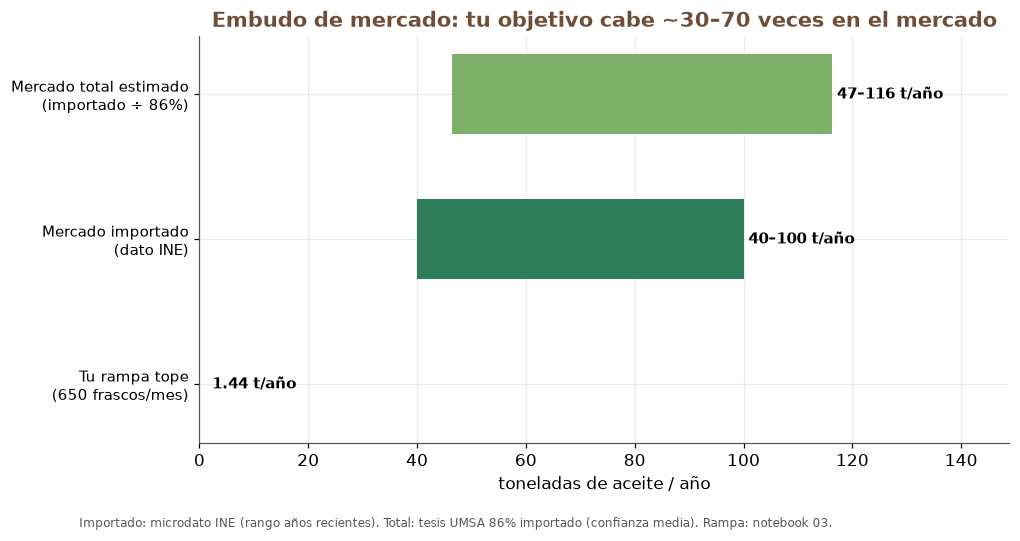

Tu rampa tope (1.4 t/año) = 1.2%–3.1% del mercado total estimado.
Lectura: NO necesitás que el mercado crezca para cumplir el plan — necesitás capturar ~2–3% de él.
El riesgo real es de DISTRIBUCIÓN (llegar a las tiendas), no de tamaño de mercado.


In [2]:
imp_bajo, imp_alto = 40.0, 100.0        # t/año (INE, años recientes)
total_bajo, total_alto = imp_bajo/0.86, imp_alto/0.86
objetivo_t = 650 * 0.2 * 12 * 0.92 / 1000   # 650 frascos/mes de 200 ml -> t/año (densidad 0.92)

niveles = ["Mercado total estimado\n(importado ÷ 86%)", "Mercado importado\n(dato INE)",
           "Tu rampa tope\n(650 frascos/mes)"]
bajos = [total_bajo, imp_bajo, objetivo_t]
altos = [total_alto, imp_alto, objetivo_t]

fig, ax = plt.subplots(figsize=(9.5, 4.8))
y = np.arange(len(niveles))[::-1]
ax.barh(y, [a-b for a, b in zip(altos, bajos)], left=bajos,
        color=[COCO["verde_claro"], COCO["verde"], COCO["acento"]], height=0.55)
for yy, (b, a) in zip(y, zip(bajos, altos)):
    txt = f" {b:,.0f}–{a:,.0f} t/año" if a > b else f" {b:,.2f} t/año"
    ax.text(max(a, b), yy, txt, va="center", fontweight="bold", fontsize=10)
ax.set_yticks(y, niveles, fontsize=10)
ax.set_xlabel("toneladas de aceite / año")
ax.set_title("Embudo de mercado: tu objetivo cabe ~30–70 veces en el mercado")
ax.set_xlim(0, total_alto * 1.28)
plt.figtext(0.01, -0.05, "Importado: microdato INE (rango años recientes). Total: tesis UMSA 86% importado (confianza media). Rampa: notebook 03.",
            fontsize=8, color=COCO["gris"])
guardar("16_embudo_demanda")
plt.show()

print(f"Tu rampa tope ({objetivo_t:.1f} t/año) = {objetivo_t/total_alto*100:.1f}%–{objetivo_t/total_bajo*100:.1f}% del mercado total estimado.")
print("Lectura: NO necesitás que el mercado crezca para cumplir el plan — necesitás capturar ~2–3% de él.")
print("El riesgo real es de DISTRIBUCIÓN (llegar a las tiendas), no de tamaño de mercado.")


### 2.1 ¿Dónde está la demanda?

Tres ciudades concentran el poder de compra — y coinciden con el destino de las importaciones (Santa Cruz 63 %, Cochabamba 27 %, La Paz 8 %, notebook 01). Señales del nicho salud: canal naturista en expansión (Natural Farma: 7 sucursales), comunidad keto activa (Keto Market La Paz ~9,6k likes) y la competencia entera vive de redes + WhatsApp.

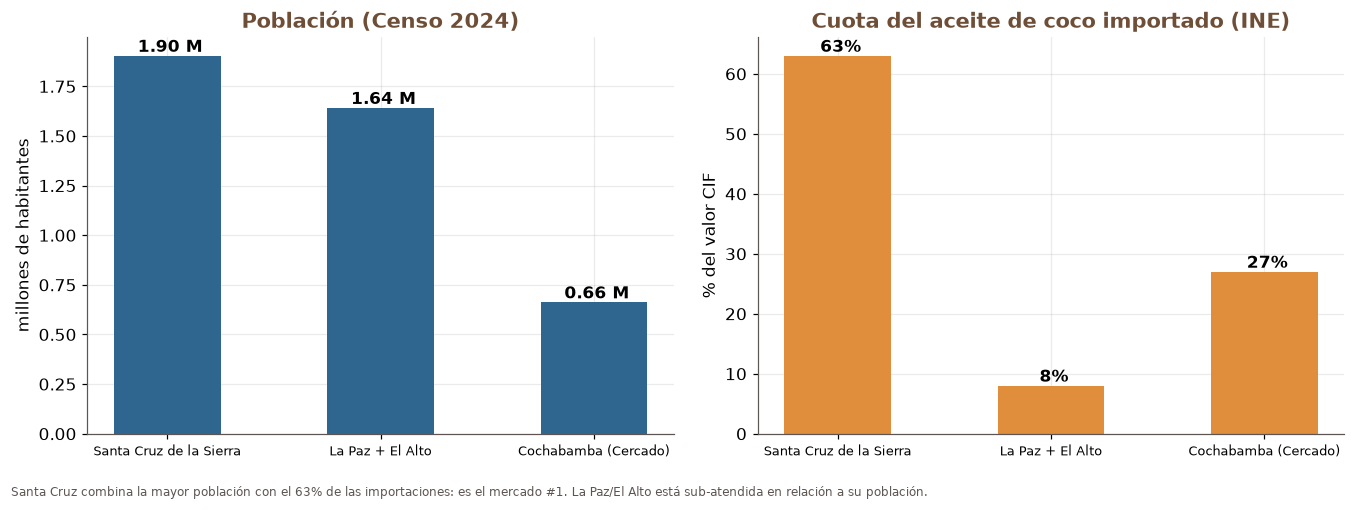

In [3]:
ciudades = pd.DataFrame({
    "ciudad": ["Santa Cruz de la Sierra", "La Paz + El Alto", "Cochabamba (Cercado)"],
    "poblacion": [1903398, 1640767, 661484],
    "cuota_importaciones_pct": [63, 8, 27],
})
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].bar(ciudades["ciudad"], ciudades["poblacion"]/1e6, color=COCO["azul"], width=0.5)
for x, v in zip(ciudades["ciudad"], ciudades["poblacion"]):
    axes[0].text(x, v/1e6, f" {v/1e6:.2f} M", ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Población (Censo 2024)")
axes[0].set_ylabel("millones de habitantes")
axes[0].tick_params(axis="x", labelsize=8.5)

axes[1].bar(ciudades["ciudad"], ciudades["cuota_importaciones_pct"], color=COCO["acento"], width=0.5)
for x, v in zip(ciudades["ciudad"], ciudades["cuota_importaciones_pct"]):
    axes[1].text(x, v, f" {v}%", ha="center", va="bottom", fontweight="bold")
axes[1].set_title("Cuota del aceite de coco importado (INE)")
axes[1].set_ylabel("% del valor CIF")
axes[1].tick_params(axis="x", labelsize=8.5)
plt.figtext(0.01, -0.04, "Santa Cruz combina la mayor población con el 63% de las importaciones: es el mercado #1. La Paz/El Alto está sub-atendida en relación a su población.",
            fontsize=8, color=COCO["gris"])
plt.tight_layout()
guardar("17_ciudades")
plt.show()


## 3. Oferta — el mapa real del coco boliviano

La producción documentada está en la **provincia Ichilo y Warnes (Santa Cruz)** — no en
el Chapare como suponíamos. Actor clave identificado: la **Organización de Mujeres San
Juan 23** (comunidad La Enconada, San Juan de Yapacaní) que ejecuta un plan de
*producción y comercialización de coco* financiado por el programa estatal **PAR III**
— el primer contacto lógico para asegurar materia prima.

,zona,municipio,hectareas,quintales_anio,toneladas_anio_aprox,actores,fuente,confianza
0,Ichilo (Santa Cruz),San Juan de Yapacani,28.5,8340.0,384.0,Colonias japonesas; Organizacion de Mujeres Sa...,Instituto Cruceno de Estadistica (proyeccion 2...,media
1,Warnes (Santa Cruz),Warnes,20.0,NaN,NaN,Proyecto privado de cultivo de palma de coco (...,Instituto Cruceno de Estadistica,media
2,Ichilo (Santa Cruz),Buena Vista,12.6,2250.0,104.0,NaN,Instituto Cruceno de Estadistica,media
3,Ichilo (Santa Cruz),San Carlos,3.0,1800.0,83.0,Vocacion fruticola (Capital del Cacao),Instituto Cruceno de Estadistica,media
4,Ichilo (Santa Cruz),Yapacani,2.6,77.0,4.0,NaN,Instituto Cruceno de Estadistica,media
5,Sara (Santa Cruz),Portachuelo,NaN,NaN,NaN,Mencionado sin cifras,Instituto Cruceno de Estadistica,baja
6,Norte de La Paz,San Buenaventura,NaN,NaN,NaN,Suelo apto; palmas actuales sin explotacion co...,Tesis UMSA 20500,baja
7,Chapare (Cochabamba),—,NaN,NaN,NaN,SIN COCO DOCUMENTADO (fruticultura = palmito/c...,Los Tiempos / busquedas,media
8,Beni y Pando,—,NaN,NaN,NaN,Economia de palmeras silvestres (acai/majo); s...,Sustainable Bolivia / Conservacion Amazonica,media


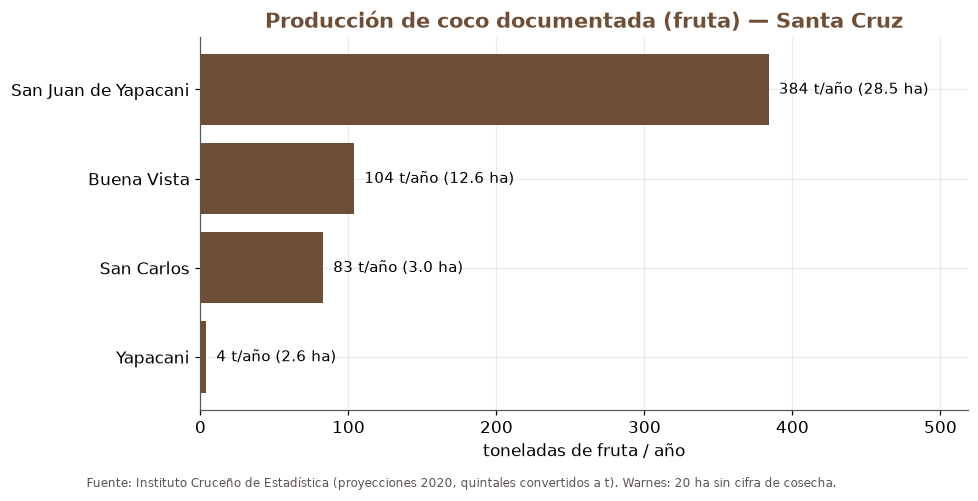

Producción documentada de fruta: ~575 t/año (solo Ichilo, sin Warnes).
Tu necesidad a rampa tope: ~14,444 cocos/año ≈ 18.8 t de fruta = 3.3% de esa producción.
Lectura: la materia prima local ALCANZA para tu escala — el desafío es asegurar el canal
de compra (acuerdo con productores de San Juan), no el volumen.


In [4]:
display(ofe)

con_datos = ofe.dropna(subset=["toneladas_anio_aprox"]).sort_values("toneladas_anio_aprox")
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.barh(con_datos["municipio"], con_datos["toneladas_anio_aprox"], color=COCO["marron"])
for y, (v, h) in enumerate(zip(con_datos["toneladas_anio_aprox"], con_datos["hectareas"])):
    ax.text(v, y, f"  {v:,.0f} t/año ({h:,.1f} ha)", va="center", fontsize=9.5)
ax.set_title("Producción de coco documentada (fruta) — Santa Cruz")
ax.set_xlabel("toneladas de fruta / año")
ax.set_xlim(0, con_datos["toneladas_anio_aprox"].max() * 1.35)
plt.figtext(0.01, -0.05, "Fuente: Instituto Cruceño de Estadística (proyecciones 2020, quintales convertidos a t). Warnes: 20 ha sin cifra de cosecha.",
            fontsize=8, color=COCO["gris"])
guardar("18_oferta_local")
plt.show()

total_fruta = con_datos["toneladas_anio_aprox"].sum()
# Tu necesidad a rampa tope: 650 frascos/mes ≈ 1.203 cocos/mes (120 ml/coco, 10% merma), coco ≈ 1,3 kg
cocos_anio = 650 * (200/120/0.9) * 12
fruta_necesaria = cocos_anio * 1.3 / 1000
print(f"Producción documentada de fruta: ~{total_fruta:,.0f} t/año (solo Ichilo, sin Warnes).")
print(f"Tu necesidad a rampa tope: ~{cocos_anio:,.0f} cocos/año ≈ {fruta_necesaria:,.1f} t de fruta = {fruta_necesaria/total_fruta*100:.1f}% de esa producción.")
print("Lectura: la materia prima local ALCANZA para tu escala — el desafío es asegurar el canal")
print("de compra (acuerdo con productores de San Juan), no el volumen.")


## 4. Conclusiones

| Pregunta | Respuesta |
|---|---|
| ¿El mercado aguanta la rampa? | **Sí, con margen**: la rampa tope (1,6 t/año) es ~2–3 % del mercado estimado (47–116 t/año). El riesgo es de **distribución**, no de tamaño. |
| ¿Dónde vender primero? | **Santa Cruz** (1,9 M hab. + 63 % de las importaciones). Cochabamba segundo. **La Paz/El Alto** (1,6 M hab., solo 8 % del importado) parece **sub-atendida** — posible oportunidad. |
| ¿Hay coco boliviano? | **Sí, en Ichilo (San Juan ~384 t/año) y Warnes** — NO en el Chapare (corrección). Tu necesidad a tope es ~3 % de la producción local documentada. |
| ¿Primer contacto de materia prima? | **Organización de Mujeres San Juan 23** (La Enconada, San Juan de Yapacaní) — ya comercializa coco con apoyo del PAR III. Contacto vía EMPODERAR/PAR III. |

### Advertencias de honestidad
- El "86 % importado" viene de **una tesis de grado** (confianza media) — el tamaño total del mercado es la cifra más blanda de este análisis.
- Las hectáreas/cosechas del ICE son **proyecciones a 2020** — la misión de campo (§`campo/`) debe verificar volúmenes y precios actuales en San Juan.
- No fue posible medir Google Trends ni consumo per cápita comparable desde este entorno.
